In [1]:
import sys
sys.path.append('./models/')
from Model import Model
from Arima import ARIMA_Model, VAR_m
from exponential_regression import ExponentialRegression, MultiDimensionalExponentialRegression
from SIRH  import *
from LinearRegression import *
from BayesianRegression import *
from moving_average import MovingAverage, MovingAverageMulti
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from evaluate_model import evaluate_model, evaluate_model_multi, evaluate_model_multi_RMSE, evaluate_model_RMSE
import json
import warnings
from scipy.stats import nbinom
from scipy.interpolate import interp1d
#warnings.filterwarnings('ignore')
warnings.filterwarnings(action='once')

In [2]:
#For plotting lines with colour gradients
from collections import deque
from itertools import islice
from matplotlib import collections as mc
from matplotlib.colors import colorConverter

In [3]:
def sliding_window(iterable, n):
  """
  sliding_window('ABCDEFG', 4) -> ABCD BCDE CDEF DEFG
  
  recipe from python docs
  """
  it = iter(iterable)
  window = deque(islice(it, n), maxlen=n)
  if len(window) == n:
      yield tuple(window)
  for x in it:
      window.append(x)
      yield tuple(window)

In [4]:
def color_gradient(x, y, c1, c2):
  """
  Creates a line collection with a gradient from colors c1 to c2,
  from data x and y.
  """
  n = len(x)
  if len(y) != n:
    raise ValueError('x and y data lengths differ')
  return mc.LineCollection(sliding_window(zip(x, y), 2),
                           colors=np.linspace(colorConverter.to_rgb(c1),
                                              colorConverter.to_rgb(c2), n - 1))

In [5]:
df=pd.read_csv('./all_pandemics/pandemic_0_1.csv')

df.index=['n_hospitalized', 'n_infectious', 'mobility', 'R_eff']
df.drop(columns=['Unnamed: 0'], inplace=True)
#plt.plot(df.loc['n_hospitalized'])

330 306


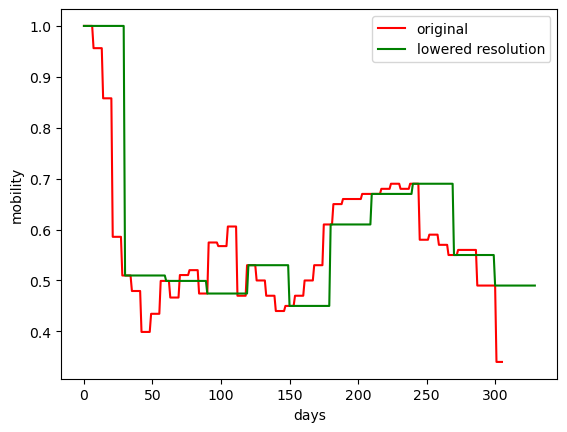

In [15]:
#Resolution
frequency=30
day=120
n_hospitalized=np.array(df.loc['n_hospitalized'])
n_infectious=np.array(df.loc['n_infectious'])
mobility=np.array(df.loc['mobility'])

n = len(mobility)
reps = mobility[::frequency]
mobility_np = np.repeat(reps, frequency)

print(len(mobility_np),len(mobility))

#indices = np.arange(0, len(mobility[:day]), frequency)
#selected_values = mobility[indices]
#new_indices = np.arange(len(mobility))
#mobility_np = np.interp(new_indices, indices, selected_values)
#m=indices[int(np.floor(day/frequency))]
#mobility_np[m:]=mobility_np[m-1]
                    

mob_np=interp1d(np.arange(len(mobility_np[:day])),mobility_np[:day],kind="linear",fill_value="extrapolate")
mob=interp1d(np.arange(len(mobility[:day])),mobility[:day],kind="linear",fill_value="extrapolate")

plt.plot(mobility,'r',label="original")
plt.plot(mobility_np,'g',label="lowered resolution")
#plt.plot(mob_np(np.arange(len(mobility))),'g',label="2 x interp")
#plt.plot(mob(np.arange(len(mobility))),'b',label="1 x interp")
plt.ylabel('mobility')
plt.xlabel('days')
plt.legend()
plt.savefig('perturbA.pdf')

#plt.xlim(0,20)

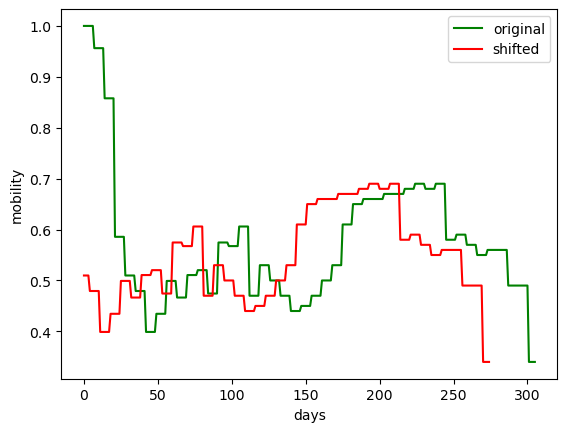

In [16]:
#Shift
shift=31

n_hospitalized=np.array(df.loc['n_hospitalized'])
n_infectious=np.array(df.loc['n_infectious'])
mobility=np.array(df.loc['mobility'])

mobility_n = mobility[shift:]
mobility_ns=np.pad(mobility_n,(0,shift), 'edge')

plt.plot(mobility,'g',label='original')
plt.plot(mobility_n,'r',label='shifted')
plt.ylabel('mobility')
plt.xlabel('days')
plt.legend()
plt.savefig('perturbB.pdf')
#plt.plot(n_infectious,'g')
#plt.plot(n_infectious_n,'r')

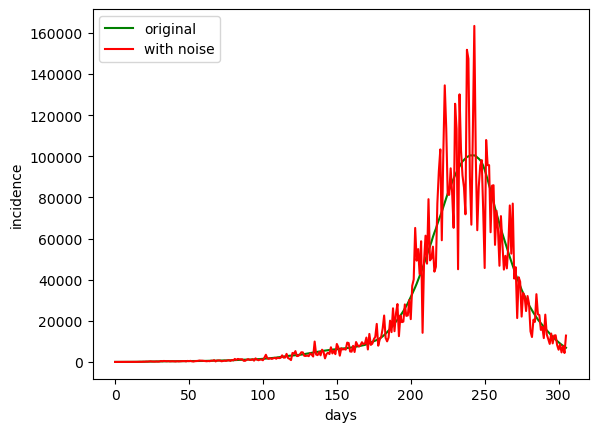

In [20]:
#Noise in incidence
k=10
rng = np.random.default_rng(0)
n_hospitalized=np.array(df.loc['n_hospitalized'])
n_infectious=np.array(df.loc['n_infectious'])
mobility=np.array(df.loc['mobility'])

I=n_infectious
lam = rng.gamma(shape=k, scale=I/np.maximum(k,1e-12))
In=rng.poisson(lam).astype(int)

plt.plot(I,'g',label='original')
plt.plot(In,'r',label='with noise')
plt.ylabel('incidence')
plt.xlabel('days')
plt.legend()
plt.savefig('perturbC.pdf')


In [18]:
print(np.logspace(-3,-1,7))
print(np.logspace(1,3,7))

[0.001      0.00215443 0.00464159 0.01       0.02154435 0.04641589
 0.1       ]
[  10.           21.5443469    46.41588834  100.          215.443469
  464.15888336 1000.        ]


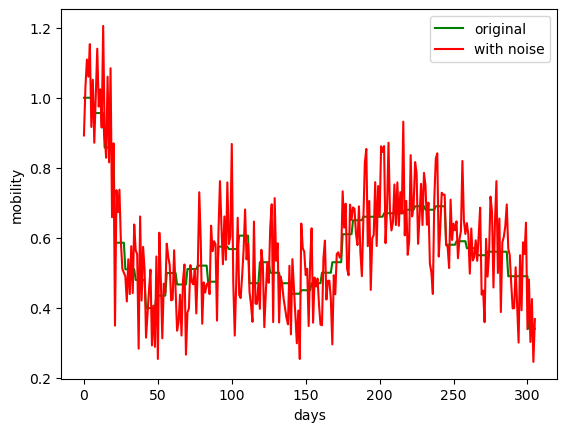

In [21]:
#Noise in mobility
sigma=.1 #[0.001,0.01,0.1]
mobility=np.array(df.loc['mobility'])

mobility_nn= mobility.copy()+np.random.normal(0, sigma, len(mobility))

plt.plot(mobility,'g',label='original')
plt.plot(mobility_nn,'r',label='with noise')
plt.ylabel('mobility')
plt.xlabel('days')
plt.legend()
plt.savefig('perturbD.pdf')
